# Fitness v4
25 de Marzo, 2025


In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Funciones auxiliares

In [5]:
# Transformación lineal
def tr_lin(x):
    return (x - 1) / (10**alpha - 1)

# Funcion lineal
def f_lin(x,y):
    return x - y

# Función polinómica con mínimo en (0,1)
def f_poly(x, y):
    return x**2 + (y - 1)**2

In [6]:
# Definimos las funciones fitness dependiendo de alfa y beta

In [7]:
def fitness_lin(ac, NP, beta):
    NPt = tr_lin(NP)
    sal = f_lin(ac,beta * NPt)
    return sal

def fitness_poly(ac, NP, beta):
    NPt = tr_lin(NP)
    sal = ac**2 + (beta * (NPt - 1)**2)
    return sal

In [8]:
# Fijamos valores para alfa y beta

In [9]:
alpha = 7
betas = [0.2, 1, 5]

In [10]:
# Preparamos el entorno para la representación gráfica

In [11]:
# Definimos el rango de valores de ac y NP
gridsize = 100
ac_vals = np.linspace(0, 1, gridsize)
NP_vals = np.linspace(1, 10**alpha, gridsize)
X, Y = np.meshgrid(ac_vals, NP_vals)

In [12]:
# Vemos las representaciones gráficas 

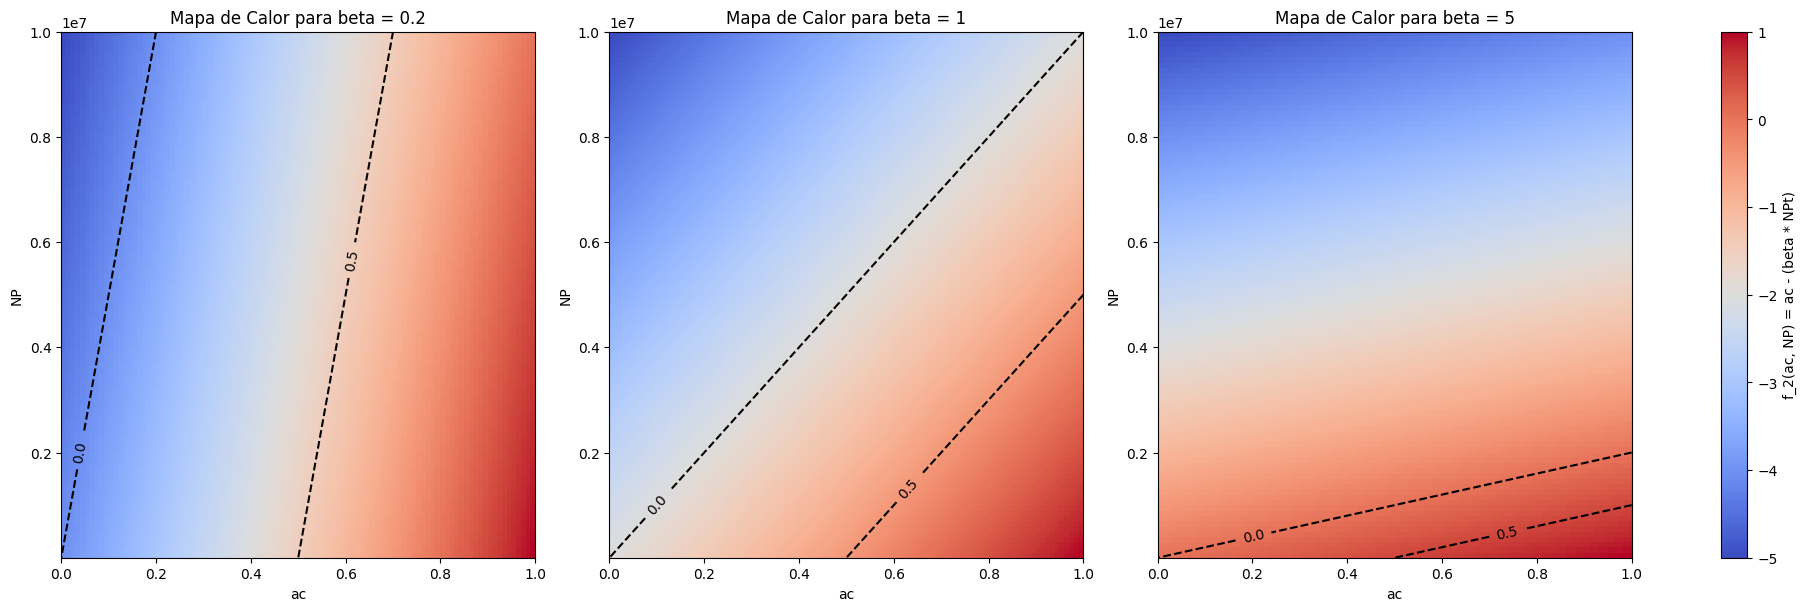

In [13]:
# Función lineal

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for ax, beta in zip(axes, betas):
    Z = fitness_lin(X, Y, beta)
    im = ax.imshow(Z, extent=[ac_vals.min(), ac_vals.max(), NP_vals.min(), NP_vals.max()],
                   origin='lower', cmap='coolwarm', aspect='auto')

    # Contornos
    contour = ax.contour(X, Y, Z, levels=[0.0, 0.5], colors='black', linestyles='dashed')
    ax.clabel(contour, fmt="%.1f", colors='black')

    ax.set_xlabel('ac')
    ax.set_ylabel('NP')
    ax.set_title(f'Mapa de Calor para beta = {beta}')

# Agregar colorbar
fig.colorbar(im, ax=axes.ravel().tolist(), label='f_2(ac, NP) = ac - (beta * NPt)')

plt.show()

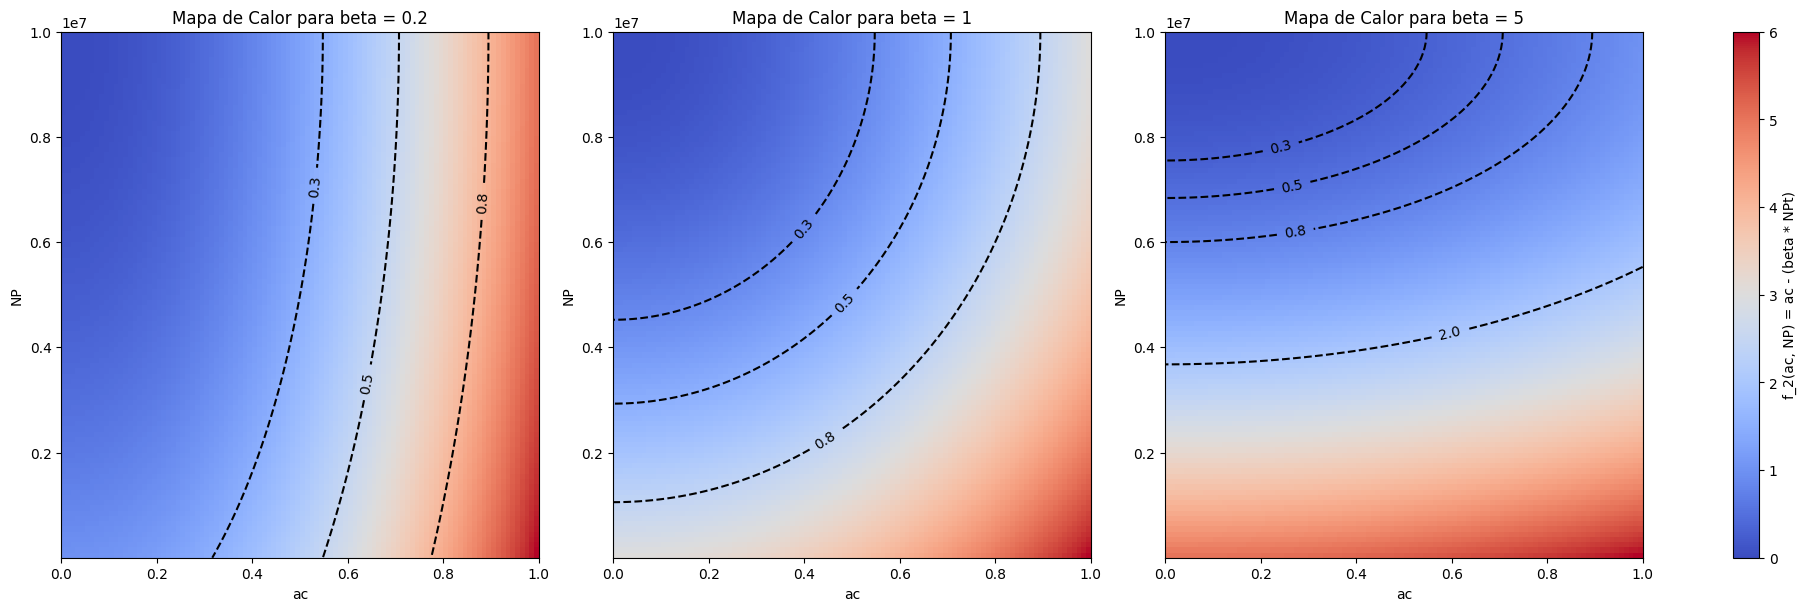

In [14]:
# Función cuadrática

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for ax, beta in zip(axes, betas):
    Z = fitness_poly(X, Y, beta)
    im = ax.imshow(Z, extent=[ac_vals.min(), ac_vals.max(), NP_vals.min(), NP_vals.max()],
                   origin='lower', cmap='coolwarm', aspect='auto')

    # Contornos
    contour = ax.contour(X, Y, Z, levels=[0.3,0.5,0.8,2.0], colors='black', linestyles='dashed')
    ax.clabel(contour, fmt="%.1f", colors='black')

    ax.set_xlabel('ac')
    ax.set_ylabel('NP')
    ax.set_title(f'Mapa de Calor para beta = {beta}')

# Agregar colorbar
fig.colorbar(im, ax=axes.ravel().tolist(), label='f_2(ac, NP) = ac - (beta * NPt)')

plt.show()

In [15]:
# Conclusión
# En ambos casos, tanto en la función lineal como la cuadrática, tenemos que si beta es pequeño el valor del accuracy 
# es mucho más importante que el número de parámetros para calcular el fitness. Si beta es muy grande, entonces el accuracy 
# deja de ser importante y el número de parámetros es determinante. Si beta bale 1, ambos parámetros, accuracy y número de 
# parámetros están compensados, esto es, un cambio del 10 por ciento de accuracy tiene el mismo efecto que un cambio del 10
# por ciento del número de parámetros.